### Google Drive Data Access Setup

The first step mounts Google Drive in the Colab environment and verifies the project data directory to ensure the required CSV file is accessible for downstream processing and analysis.

In [ ]:
import os
import hashlib, shutil, datetime
import json
import pandas as pd
import numpy as np
import re
import unicodedata

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/Capstone_Wealthtender"  # change if needed

RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
PROC_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
OUT_DIR  = os.path.join(PROJECT_ROOT, "outputs")

for d in [RAW_DIR, PROC_DIR, OUT_DIR,
          os.path.join(OUT_DIR, "eda"),
          os.path.join(OUT_DIR, "quality"),
          os.path.join(OUT_DIR, "lexical")]:
    os.makedirs(d, exist_ok=True)

print("Project ready:", PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project ready: /content/drive/MyDrive/Capstone_Wealthtender


In [ ]:
# Listing the contents of the project data directory to verify that the required files
print(os.listdir("/content/drive/MyDrive/Capstone_Wealthtender/data")[:50])

['raw', 'processed']


### Raw Data Ingestion & Integrity Check

This step copies the source CSV into the project’s raw data directory using a date-stamped filename and generates a SHA-256 hash and file metadata to ensure data integrity and reproducibility


In [ ]:
# Uploading raw file on the drive
SOURCE_CSV = os.path.join(PROJECT_ROOT, "/content/drive/MyDrive/Capstone_Wealthtender/data/raw/Imported table-Grid view.csv")  # adjust if needed

today = datetime.datetime.now().strftime("%Y%m%d")
RAW_CSV = os.path.join(RAW_DIR, f"reviews_{today}.csv")

# buidling a copy of raw file only if not already copied
if not os.path.exists(RAW_CSV):
    shutil.copy2(SOURCE_CSV, RAW_CSV)

def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

meta = {
    "raw_csv": RAW_CSV,
    "sha256": sha256_file(RAW_CSV),
    "bytes": os.path.getsize(RAW_CSV)
}
meta


{'raw_csv': '/content/drive/MyDrive/Capstone_Wealthtender/data/raw/reviews_20260128.csv',
 'sha256': 'dcb841466059464f6545b644bd592407bae3d7d8ed178505dbbbd069ec80a23f',
 'bytes': 3784833}

In [ ]:
# Save raw data metadata as a JSON artifact to support data lineage, auditability, and reproducibility
meta_path = os.path.join(OUT_DIR, "quality", f"raw_file_meta_{today}.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print("Saved:", meta_path)


Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/quality/raw_file_meta_20260128.json


### Data Loading & Initial Standardization

This step loads the raw review dataset, standardizes column names, and robustly parses date fields while performing basic structural checks to confirm required columns and dataset shape.


In [ ]:
df = pd.read_csv(RAW_CSV)

# standardize column names (safe)
df.columns = [c.strip() for c in df.columns]

# Parse dates robustly
for col in ["Date", "Post Modified Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Basic checks
expected = ["notification_page", "notification_name", "Content", "acf_rating"]
missing_expected = [c for c in expected if c not in df.columns]
print("Missing expected:", missing_expected)

print("Shape:", df.shape)
df.head(3)

Missing expected: []
Shape: (4822, 15)


,ID,Title,Content,Date,_custom_form,notification_name,notification_page,_custom_relationship,_custom_compensation,_custom_conflicts,_custom_disclosure,Status,Post Modified Date,reviewer_name,acf_rating
0,55476,Absolutely amazing!!!,Omar Morillo is an exceptional wealth advisor ...,2026-01-07 15:15:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,NaN,publish,2026-01-07 15:15:00,Alyssa Sussman,5.0
1,55446,It is Simply wonderful working with Omar,Omar is an exceptional advisor. Beyond the out...,2026-01-06 20:44:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,NaN,publish,2026-01-06 20:44:00,Nayarit Briceno,5.0
2,55445,President,We are extremely happy with the work Omar Mori...,2026-01-06 20:44:00,40855,"Omar A. Morillo, CFP®, ChFC®, AIF®",https://wealthtender.com/financial-advisors/om...,Current Client,This reviewer received no compensation for thi...,There are no material conflicts of interest.,NaN,publish,2026-01-06 20:44:00,Gregory Gutt,5.0


### Standardizing Review Fields and Evaluating Data Quality

This step standardizes advisor identifiers, review text, ratings, and dates to create a clean, analysis-ready dataset, and then evaluates overall data completeness and quality by summarizing coverage, missingness, and key dataset statistics.

In [ ]:
# using the advisor’s profile URL (notification_page), and falling back to the advisor name if the URL is missing
df["advisor_id"] = df["notification_page"].fillna(df["notification_name"]).astype(str).str.strip()
df["advisor_name"] = df["notification_name"].astype(str).str.strip()
df["review_text_raw"] = df["Content"].fillna("").astype(str)
df["rating"] = pd.to_numeric(df["acf_rating"], errors="coerce")
# using the original review date when available, and filling missing dates with the post-modified date as a fallback.
df["review_date"] = df["Date"]
if "Post Modified Date" in df.columns:
    df["review_date"] = df["review_date"].fillna(df["Post Modified Date"])

In [ ]:
def missing_report(d):
    return (d.isna().mean().sort_values(ascending=False)
            .rename("missing_frac").to_frame()
            .assign(missing_count=d.isna().sum()))

quality = {
    "n_rows": len(df),
    "n_cols": df.shape[1],
    "n_advisors": df["advisor_id"].nunique(),
    "n_names": df["advisor_name"].nunique(),
    "date_min": str(df["review_date"].min()),
    "date_max": str(df["review_date"].max()),
    "rating_missing_frac": float(df["rating"].isna().mean()),
    "text_empty_frac": float((df["review_text_raw"].str.strip() == "").mean()),
}

quality_df = missing_report(df)

quality, quality_df.head(10)

({'n_rows': 4822,
  'n_cols': 20,
  'n_advisors': 339,
  'n_names': 364,
  'date_min': '2008-11-24 18:00:00',
  'date_max': '2026-01-07 15:15:00',
  'rating_missing_frac': 0.013894649523019494,
  'text_empty_frac': 0.00041476565740356696},
                       missing_frac  missing_count
 _custom_disclosure        0.912070           4398
 reviewer_name             0.013895             67
 rating                    0.013895             67
 acf_rating                0.013895             67
 _custom_conflicts         0.011199             54
 _custom_compensation      0.011199             54
 _custom_relationship      0.010369             50
 Content                   0.000207              1
 notification_page         0.000207              1
 notification_name         0.000207              1)

In [ ]:
## Saving data quality summary metrics and  missing-value diagnostics as versioned artifacts for downstream analysis
quality_path = os.path.join(OUT_DIR, "quality", f"quality_summary_{today}.json")
with open(quality_path, "w") as f:
    json.dump(quality, f, indent=2)

quality_df_path = os.path.join(OUT_DIR, "quality", f"missing_report_{today}.csv")
quality_df.to_csv(quality_df_path, index=True)

print("Saved:", quality_path)
print("Saved:", quality_df_path)

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/quality/quality_summary_20260128.json
Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/quality/missing_report_20260128.csv


### Exploratory Data Analysis and Review Quality Assessment

This step explores dataset scale, advisor coverage, rating distributions, and review volume per advisor while assessing review text length and potential noise through token-based heuristics to inform downstream modeling and filtering decisions.

In [ ]:
# Performing exploratory data analysis to summarize dataset scale, advisor coverage, rating distributions, review volume, and text-length–based noise characteristics.

eda = {}

eda["reviews"] = df["review_text_raw"].notna().sum()
eda["advisors"] = df["advisor_id"].nunique()

# Ratings distribution
eda["rating_counts"] = df["rating"].value_counts(dropna=False).sort_index()

# Reviews per advisor
rev_per_adv = df.groupby("advisor_id").size().sort_values(ascending=False)
eda["rev_per_adv_summary"] = rev_per_adv.describe()

# Short review heuristics
def token_count(s):
    return len(str(s).split())

df["token_count"] = df["review_text_raw"].map(token_count)
eda["token_count_summary"] = df["token_count"].describe()

# “noise” thresholds (tune later)
eda["pct_under_20_tokens"] = float((df["token_count"] < 20).mean())
eda["pct_under_50_tokens"] = float((df["token_count"] < 50).mean())

eda

{'reviews': np.int64(4822),
 'advisors': 339,
 'rating_counts': rating
 1.0       4
 2.0       2
 3.0       2
 4.0      33
 5.0    4714
 NaN      67
 Name: count, dtype: int64,
 'rev_per_adv_summary': count    339.000000
 mean      14.224189
 std       16.622947
 min        1.000000
 25%        5.000000
 50%        9.000000
 75%       17.000000
 max      144.000000
 dtype: float64,
 'token_count_summary': count    4822.000000
 mean       76.576109
 std        66.588969
 min         0.000000
 25%        36.000000
 50%        63.000000
 75%       101.000000
 max      2048.000000
 Name: token_count, dtype: float64,
 'pct_under_20_tokens': 0.11654914973040233,
 'pct_under_50_tokens': 0.3726669431771049}

In [ ]:
#saving EDA summary as a versioned JSON artifact
eda_path = os.path.join(OUT_DIR, "eda", f"eda_summary_{today}.json")
with open(eda_path, "w") as f:
    json.dump({k: (v.to_dict() if hasattr(v, "to_dict") else v) for k,v in eda.items()}, f, indent=2, default=str)
print("Saved:", eda_path)

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/eda/eda_summary_20260128.json


### Visualizing Review Distribution and Engagement Patterns

This step gives visualizations to analyze rating distributions, review volume trends over time, advisor-level review concentration, and review length characteristics, supporting intuitive pattern discovery and data quality validation by visually examining relationships between ratings, review frequency, and textual depth.


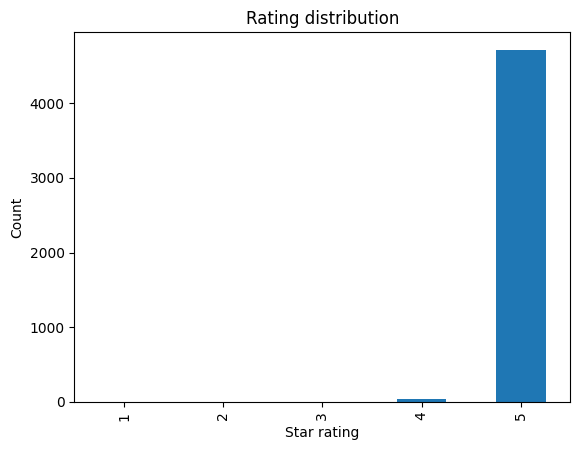

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/eda/rating_distribution_20260128.png


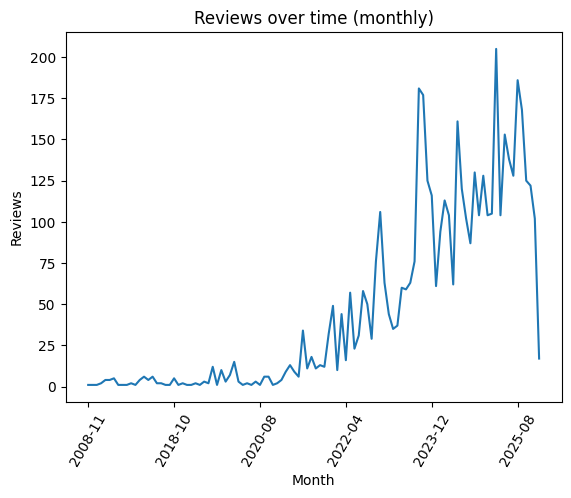

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/eda/reviews_over_time_20260128.png


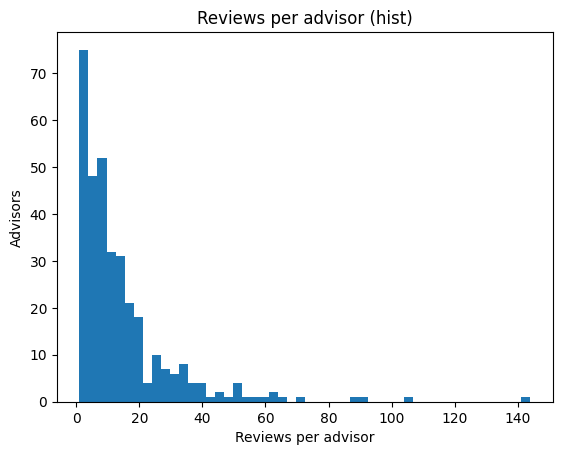

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/eda/reviews_per_advisor_hist_20260128.png


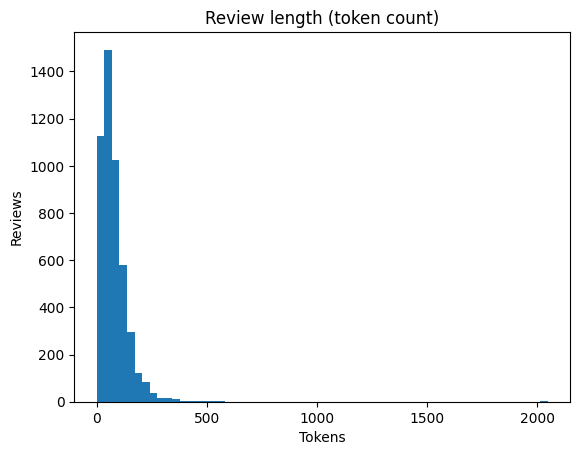

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/eda/token_count_hist_20260128.png


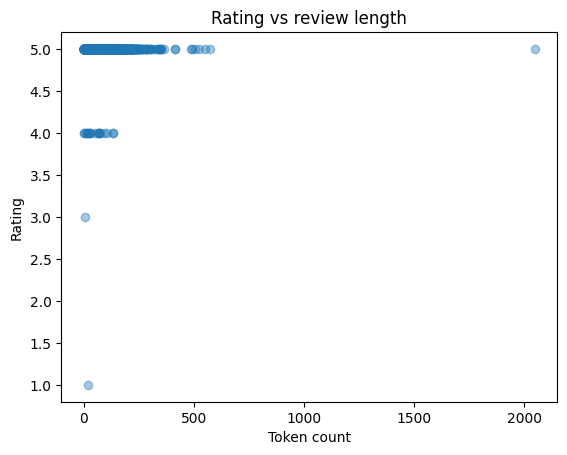

Saved: /content/drive/MyDrive/Capstone_Wealthtender/outputs/eda/rating_vs_token_scatter_20260128.png


In [ ]:
import matplotlib.pyplot as plt

def savefig(name):
    path = os.path.join(OUT_DIR, "eda", f"{name}_{today}.png")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()
    print("Saved:", path)

# 1) Rating distribution
plt.figure()
df["rating"].dropna().astype(int).value_counts().sort_index().plot(kind="bar")
plt.title("Rating distribution")
plt.xlabel("Star rating")
plt.ylabel("Count")
plt.show()
savefig("rating_distribution")

# 2) Reviews per month
plt.figure()
tmp = df.dropna(subset=["review_date"]).copy()
tmp["month"] = tmp["review_date"].dt.to_period("M").astype(str)
tmp.groupby("month").size().plot(kind="line")
plt.title("Reviews over time (monthly)")
plt.xlabel("Month")
plt.ylabel("Reviews")
plt.xticks(rotation=60)
plt.show()
savefig("reviews_over_time")

# 3) Reviews per advisor (histogram)
plt.figure()
rev_per_adv = df.groupby("advisor_id").size()
plt.hist(rev_per_adv, bins=50)
plt.title("Reviews per advisor (hist)")
plt.xlabel("Reviews per advisor")
plt.ylabel("Advisors")
plt.show()
savefig("reviews_per_advisor_hist")

# 4) Token count distribution
plt.figure()
plt.hist(df["token_count"], bins=60)
plt.title("Review length (token count)")
plt.xlabel("Tokens")
plt.ylabel("Reviews")
plt.show()
savefig("token_count_hist")

# 5) Rating vs token count scatter (sample for readability)
plt.figure()
sample = df.dropna(subset=["rating"]).sample(min(len(df), 2000), random_state=42)
plt.scatter(sample["token_count"], sample["rating"], alpha=0.4)
plt.title("Rating vs review length")
plt.xlabel("Token count")
plt.ylabel("Rating")
plt.show()
savefig("rating_vs_token_scatter")


### Advisor level coverage
Below step is quantifying advisor-level review coverage and data sparsity by summarizing review counts and low-sample thresholds to assess the reliability of advisor-level insights.

In [ ]:
# Calculating advisor review coverage to identify low-data advisors and assess sparsity.

rev_per_adv = df.groupby("advisor_id").size()

coverage = {
    "advisors_total": int(rev_per_adv.shape[0]),
    "pct_advisors_lt3": float((rev_per_adv < 3).mean()),
    "pct_advisors_lt5": float((rev_per_adv < 5).mean()),
    "pct_advisors_lt10": float((rev_per_adv < 10).mean()),
    "median_reviews_per_advisor": float(rev_per_adv.median()),
    "p90_reviews_per_advisor": float(rev_per_adv.quantile(0.90)),
}

coverage_path = os.path.join(OUT_DIR, "eda", f"coverage_{today}.json")
with open(coverage_path, "w") as f:
    json.dump(coverage, f, indent=2)
coverage


{'advisors_total': 339,
 'pct_advisors_lt3': 0.18289085545722714,
 'pct_advisors_lt5': 0.24778761061946902,
 'pct_advisors_lt10': 0.5162241887905604,
 'median_reviews_per_advisor': 9.0,
 'p90_reviews_per_advisor': 33.0}

### Normalizing and Standardizing Review Text for Analysis

This step is cleaning and normalizing raw review text by removing formatting noise, boilerplate disclosures, and web artifacts while preserving semantic structure, and is generating audit-ready, NLP-safe features for downstream analysis and modeling.


In [ ]:
# ============================
# Effective cleaning + normalization for review_text_raw (inline, no function)
# ============================

# 0) Start from raw and keep a clean working copy (do NOT overwrite raw)
df["review_text_clean"] = df["review_text_raw"].copy()

# 1) Handle missing values + enforce string type safely
df["review_text_clean"] = df["review_text_clean"].fillna("").astype(str)

# 2) Normalize unicode (keeps meaning but standardizes characters like smart quotes)
df["review_text_clean"] = df["review_text_clean"].apply(lambda x: unicodedata.normalize("NFKC", x))

# 3) Standardize line breaks/tabs into spaces (turn multi-line reviews into single-line text)
df["review_text_clean"] = df["review_text_clean"].str.replace(r"[\r\n\t]+", " ", regex=True)

# 4) Remove URLs (common scrape noise)
df["review_text_clean"] = df["review_text_clean"].str.replace(r"http\S+|www\.\S+|www\S+", " ", regex=True)

# 5) Remove emails (rare but noisy if present)
df["review_text_clean"] = df["review_text_clean"].str.replace(r"\S+@\S+", " ", regex=True)

# 6) Remove bullets / separator glyphs (copy-paste artifacts)
df["review_text_clean"] = df["review_text_clean"].str.replace(r"[•▪►◆■│]+", " ", regex=True)

# 7) Remove platform boilerplate disclaimers ONLY if present (keeps normal phrases intact)
#    (Patterns are strict so you don’t accidentally remove real content.)
BOILERPLATE_PATTERNS = [
    r"this reviewer received no compensation.*",
    r"there are no material conflicts of interest.*",
]
for pat in BOILERPLATE_PATTERNS:
    df["review_text_clean"] = df["review_text_clean"].str.replace(pat, " ", regex=True, flags=re.IGNORECASE)

# 8) Normalize whitespace again (after removals)
df["review_text_clean"] = df["review_text_clean"].str.replace(r"\s+", " ", regex=True).str.strip()

# 9) Normalize exaggerated punctuation + stretched letters (light-touch)
#    Keeps punctuation; only collapses extreme repeats.
df["review_text_clean"] = df["review_text_clean"].str.replace(r"([!?.,])\1{2,}", r"\1", regex=True)  # "!!!" -> "!"
df["review_text_clean"] = df["review_text_clean"].str.replace(r"(.)\1{3,}", r"\1\1", regex=True)     # "soooo" -> "soo"

# 10) Lowercase for consistency (good for classic NLP; embeddings don't require it)
df["review_text_clean"] = df["review_text_clean"].str.lower()

# 11) Create token counts on cleaned text (useful for noise thresholds)
df["clean_token_count"] = df["review_text_clean"].str.split().str.len()

# 12) Drop empty / near-empty reviews created after cleaning (adjust threshold if needed)
df = df[df["review_text_clean"].str.len() > 5].copy()

# 13) Track cleaning impact
df["raw_len"] = df["review_text_raw"].fillna("").astype(str).str.len()
df["clean_len"] = df["review_text_clean"].str.len()

print("Number of reviews after cleaning:", df.shape[0] )
print("Avg raw length:", df["raw_len"].mean())
print("Avg clean length:", df["clean_len"].mean())
print("Pct under 20 tokens:", float((df["clean_token_count"] < 20).mean()))
df[["review_text_raw", "review_text_clean", "raw_len", "clean_len", "clean_token_count"]].head(5)


Number of reviews after cleaning: 4731
Avg raw length: 458.99217924328894
Avg clean length: 457.3741280913126
Pct under 20 tokens: 0.09955611921369689


,review_text_raw,review_text_clean,raw_len,clean_len,clean_token_count
0,Omar Morillo is an exceptional wealth advisor ...,omar morillo is an exceptional wealth advisor ...,516,516,93
1,Omar is an exceptional advisor. Beyond the out...,omar is an exceptional advisor. beyond the out...,316,316,47
2,We are extremely happy with the work Omar Mori...,we are extremely happy with the work omar mori...,891,888,142
3,always available for any questions or concerns...,always available for any questions or concerns...,157,157,26
4,Omar was referred to me by my accountant to he...,omar was referred to me by my accountant to he...,558,558,91


In [ ]:
# Saving the cleaned and normalized review dataset as a versioned artifact for downstream modeling and analysis
processed_path = os.path.join(PROC_DIR, f"reviews_clean_{today}.csv")
df.to_csv(processed_path, index=False)
print("Saved:", processed_path)

Saved: /content/drive/MyDrive/Capstone_Wealthtender/data/processed/reviews_clean_20260128.csv


### Performing Linguistic Exploratory Analysis on Review Text

This step is tokenizing cleaned review text to analyze the frequency of individual words and consecutive word pairs in order to identify dominant language patterns and potential repetition.  
It is surfacing and persisting common unigrams and bigrams as structured artifacts to support signal-versus-noise assessment and downstream text mod


In [ ]:

# Linguistic EDA (unigrams, bigrams, repeated text)
# breaking all reviews into words and counting how often each word appears

from collections import Counter

def tokenize_simple(s):
    # simple tokenization (no heavy deps)
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return [w for w in s.split() if len(w) > 1]

tokens = []
for t in df["review_text_clean"].astype(str).tolist():
    tokens.extend(tokenize_simple(t))

top_words = Counter(tokens).most_common(40)
print("Top 10 most frequent tokens:")
for word, count in top_words[:10]:
    print(f"{word:15} {count}")

#2. analyzing pairs of consecutive words (bigrams) across all cleaned reviews

def bigrams(words):
    return list(zip(words, words[1:]))

bigram_counts = Counter()
for t in df["review_text_clean"].astype(str).tolist():
    w = tokenize_simple(t)
    bigram_counts.update(bigrams(w))

top_bigrams = bigram_counts.most_common(40)
print("Top 10 most frequent bigrams:")
for bigram, count in top_bigrams[:10]:
    print(f"{' '.join(bigram):30} {count}")


# organizing and saving the most common words and word pairs found in the reviews into CSV files

top_words_df = pd.DataFrame(top_words, columns=["token","count"])
top_bigrams_df = pd.DataFrame([(" ".join(bg), c) for bg,c in top_bigrams], columns=["bigram","count"])

top_words_df.to_csv(os.path.join(OUT_DIR, "lexical", f"top_tokens_{today}.csv"), index=False)
top_bigrams_df.to_csv(os.path.join(OUT_DIR, "lexical", f"top_bigrams_{today}.csv"), index=False)

print("Saved lexical CSVs.")


Top 10 most frequent tokens:
and             17982
to              12362
the             8660
with            7005
my              5804
of              5361
financial       5324
for             5184
in              4838
our             4777
Top 10 most frequent bigrams:
working with                   1112
has been                       1081
highly recommend               967
he is                          955
have been                      945
we have                        782
he has                         737
in the                         682
of the                         658
financial advisor              649
Saved lexical CSVs.
